# SiReNetA basic examples – "Random Walk" canonical model
Authors: **Matthieu Gilson** and **Gorka Zamora-López**


This notebook is a quick introductory example for the use of the *SiReNetA* python package. For more detailed explanations and step-by-step tutorials on *Stimulus-Response Network Analysis*, please visit the [SiReNetA – Tutorials repository](https://github.com/mb-BCA/SiReNetA_Tutorials).

--------------------

### Dependencies

*sireneta* is built using *[xarray](https://docs.xarray.dev/en/stable/#)* in order to add labelled anotations and attributes to the underlying *numpy* arrays, which are relevant for the correct analysis of the response matrices. Running this notebook thus requires a Python (>3.6) installation together with:
- *xarray* (>=2026.01.0). Labelled array support.
- *numpy* (>=1.6). Fast array operations.
- *matplotlib*. For visualizations and plotting.
- *scipy*. Not used in the notebook, but dependency of *sireneta*.
- *galib* (>=2.1). Network generation and characterization.
- *sireneta*. Stimulus-response network analysis.


#### Import the main libraries


In [1]:
# Imports from Python's standard library
from timeit import default_timer as timer
# Third-party packages
import matplotlib.pyplot as plt
%matplotlib inline
import xarray as xr
import numpy as np
import sireneta as sna
import galib   # Needed?


#### Getting information

As usual, while working in interactive sessions, built-in `help()` or IPythons' `name?` shortcut will show further details of the modules and the functions. 

> NOTE: For now, importing *sireneta* does not bring the functions in the responses.py module into the namespace. Thus, generation of response tensor is called as, e.g., `>>> sna.responses.OrnsteinUhlenbeck(con, ...)`. All other functions are imported to the first hierarchical level: `sna.function()`.


In [ ]:
help(sna)

In [ ]:
#help(sna.metrics)
help(sna.responses)

In [ ]:
#sna.GlobalResponse?
#sna.NodeResponses?
#sna.responses.RandomWalk?
sna.responses.LeakyCascade?

## Overview of basic concepts

The aim of the present Stimulus-Response Network Analysis is to investigate the properties of networks based on how stimuli propagate along the network, for different canonical models. In this notebook we use the **Random Walk** which describes the ***discrete-time*** propagation of particles on a network. Given connectivity matrix $A$ (weighted or unweighted, directed or undirected) and transition probability $T$, the evolution of the system is given by

$$\mathbf{x}_t = T \, \mathbf{x}_{t-1}.$$

Here, $x_{i,t}$ is a column vector representing the expected number of walkers found at node $i$ at time $t$. Initial conditions $\mathbf{x}_0$ denote the number of walkers initially seeded at each node. We will denote this as the initial stimulus $\mathbf{s}_0$, or `S0`.
The model has no further parameters.


## 1. Load a connectivity matrix

The folder "./Data/" contains a few sample networks for these tests. Choose one

In [2]:
## LOAD A CONNECTIVITY MATRIX

## Small sample graphs
net = np.loadtxt('Data/testnet_N8_Directed.txt').T
#net = np.loadtxt('Data/testnet_N8_Undirected.txt').T
## Path graphs
#net = np.loadtxt('Data/testnet_PathGraph_N10.txt').T
#net = np.loadtxt('Data/testnet_PathDigraph_N10.txt').T
## Structural brain connectivity
#net = np.load('Data/testnet_SC.npy').T



> WARNING! Notice that we included a `.T` at the end of the loading to transpose the adjacency matrices. The reason is that those networks were created following the graph convention (rows = outputs) but *sireneta* follows the dynamical systems convention (columns = outputs).
> - Graph theory convention $A_{ij} = 1$ means the link $i \to j$.
> - In dynamical systems $A_{ij} = 1$ means the link $i \gets j$.

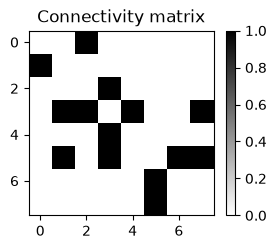

In [3]:
# Show the connectivity matrix
%matplotlib inline
plt.figure(figsize=(3.2,2.4))
plt.title( 'Connectivity matrix' )
plt.imshow(net, cmap='gray_r')
plt.colorbar();

## 2. Compute the response matrices

In this case, the model has no parameters but we first need to compute its transition probability matrix. Additionally, we need to define:
- Duration of the simulation.
- Initial conditions $\mathbf{s}_0$, as `S0vec`.

> **NOTE:** Initial conditions `S0vec` can be defined either as a number or a vector. A number will same initial conditions for all nodes while in a vector we can specify the number of particles seeded at each node.

In [4]:
# 1) Define the duration of the simulation
tfinal = 20

# 2) Define the input amplitudes as a vector
N = len(net) 
# All nodes start with one night walker
S0vec = 1
# Define initial number of walkers arbitrarily
S0vec = np.zeros(N, dtype=np.float64)
S0vec[0] = 1
S0vec[1] = 3

# 3) Finally, compute the pair-wise response matrices (response tensor)
resp_tensor = sna.responses.RandomWalk(net, S0=S0vec, tmax=tfinal)


### Exploring the `resp_tensor`

The result `resptensor` is a `xarray.DataArray` object containing a 3D numpy `ndarray` and additional metadata. The three dimensions are called: `['time', 'nodes_to', 'nodes_from']`.

> `xarray` does not allow two dimensions to have the same name (to avoid confusion when using dimension names to slice the data). Therefore, the distinction between `'nodes_to'` and `'nodes_from'`.

Much like in *pandas*, each entry along the different dimensions has their own label. Here, we didn't provide labels but they were generated automatically:
- `'time'` : (0, 1, 2, …, tfinal-1), as an `np.array` of `uint64` dtype.
- `'nodes_to'` : \['node_0', 'node_2', 'node_3', … , 'node_(N-1)'\] as an `nd.array`.
- `'nodes_from'` : \['node_0', 'node_2', 'node_3', … , 'node_(N-1)'\] as an `nd.array`.

The time dimension always gets automatically generated depending on the duration and the time-step provided for the simulation. If labels for the nodes available, these can be passed to the response tensor generation functions via the optional parameter `labels`. 

*xarray* allows for various ways to explore the content of a DataArray. Here a few key commands:
- Typing `resp_tensor` will display all information.
- `resp_tensor.values` is the underlying numpy array.
- `resp_tensor.dims` shows the names of the dimensions.
- `resp_tensor['time']` shows the information regarding the 'time' dimension.
- `resp_tensor['nodes_to']` shows the information regarding the 'nodes_to' dimension.
- `resp_tensor['time'].values` is the numpy array of the labelled indices.


In [36]:
## Displaying information regarding the dimensions
resp_tensor['time']
#resp_tensor['nodes_to']
#resp_tensor['nodes_from']

<xarray.DataArray 'time' (time: 21)> Size: 168B
array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20], dtype=uint64)
Coordinates:
  * time     (time) uint64 168B 0 1 2 3 4 5 6 7 8 ... 12 13 14 15 16 17 18 19 20

In [37]:
## The underlying values
#resp_tensor['time'].values
resp_tensor['nodes_to'].values
#resp_tensor['nodes_from'].values

array(['node_0', 'node_1', 'node_2', 'node_3', 'node_4', 'node_5',
       'node_6', 'node_7'], dtype='<U6')

In [38]:
## The length of the dimensions
resp_tensor.sizes
#resp_tensor.sizes['time']
#resp_tensor.sizes['nodes_to']
#resp_tensor.sizes['nodes_from']

Frozen({'time': 21, 'nodes_to': 8, 'nodes_from': 8})

In [39]:
## Displaying general information
resp_tensor

<xarray.DataArray (time: 21, nodes_to: 8, nodes_from: 8)> Size: 11kB
array([[[1.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 3.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [1.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
...
        [0.32020499, 0.91826949, 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.15165724, 0.48030748, 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.15165724, 0.48030748, 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.03159253, 0.09354168, 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.03054133, 0.0947776 , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.06236112, 0.18684907, 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.30608983, 0.95312229, 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.16010249, 0.45913475, 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.16010249, 0.45913475, 0.        , ..., 0.        ,
         0.        , 0.        ]]], shape=(21, 8, 8))
Coordinates:
  * time        (time) uint64 168B 0 1 2 3 4 5 6 7 8 ... 13 14 15 16 17 18 19 20
  * nodes_to    (nodes_to) <U6 192B 'node_0' 'node_1' ... 'node_6' 'node_7'
  * nodes_from  (nodes_from) <U6 192B 'node_0' 'node_1' ... 'node_6' 'node_7'
Attributes:
    model:       RandomWalk
    time_class:  discrete
    dt:          1.0
    S0:          [1. 3. 0. 0. 0. 0. 0. 0.]

### Special attributes

As seen in the data summary above, there is a list of attributes. These are not the default `xarray.DataArra` default, but user defined attributes. In this case `resp_tensor` was given the following:
- `'model'` : Underlying dynamical model.
- `'time_class'` : whether it is time-discrete or time-continuous model.
- `dt` : the time-step of the simulation.
- `S0` : the initial stimulus.

> **NOTE:** These attributes are always present in all generated response results, but other specific parameters (e.g., model parameters) will also be included.

These user-defined attributes are stored as a dictionary in `xarr.attrs` and can be recalled or iterated as any other dictionary.

In [47]:
resp_tensor.attrs

{'model': 'RandomWalk',
 'time_class': 'discrete',
 'dt': 1.0,
 'S0': array([1., 3., 0., 0., 0., 0., 0., 0.])}

In [48]:
for item in resp_tensor.attrs.items():
    print( item )

('model', 'RandomWalk')
('time_class', 'discrete')
('dt', 1.0)
('S0', array([1., 3., 0., 0., 0., 0., 0., 0.]))


### Visualise some pair-wise responses


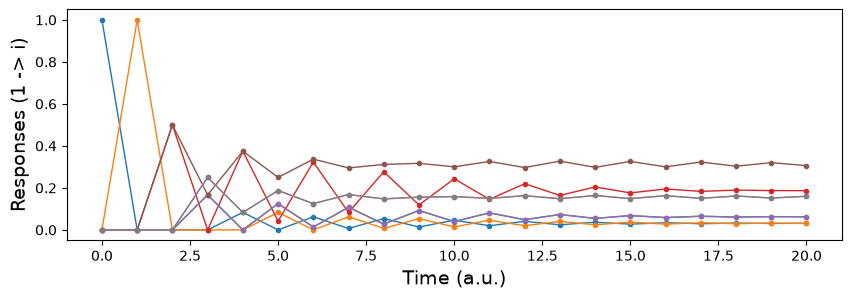

In [5]:
# Plot the pair-wise responses of all nodes, to the initial stimulus on node_0

# Get the x-axis from the 'time' dimension of the response object
tpoints = resp_tensor['time'].values

plt.figure(figsize=(10,3))
# Add the responses from all nodes to input at first node
for i in range(N):
    plt.plot(tpoints, resp_tensor.values[:,i,0], '.-', lw=1) 
plt.xlabel( 'Time (a.u.)' );
plt.ylabel( 'Responses (1 -> i)' );
#plt.tight_layout()

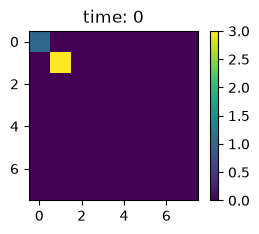

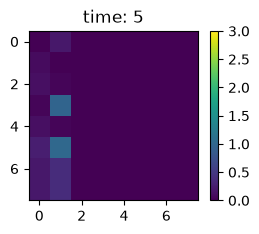

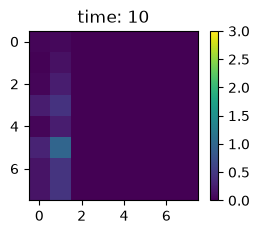

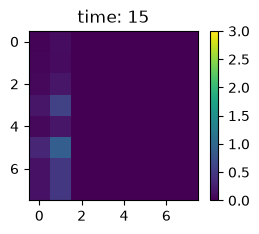

In [6]:
# Plot some response matrices
cmax = resp_tensor.attrs['S0'].max()

for t in range(0,tfinal,5):
    plt.figure(figsize=(3.,2.2))
    plt.title( 'time: %d' %t )
    plt.imshow(resp_tensor.values[t])    
    plt.clim(0,cmax)
    plt.colorbar()

## 3. Extract and visualise various metrics

#### Some global properties

- The **global response** is the sum of all pair-wise responses at each time-point. Optional parameter `selfresp` allows to include or exclude from the sum, the response that each node elicits on itself.
- **Diversity** is the coefficient of variation among the pairs-wise responses, at each time point. (No `selfresp` parameter, but it should have that too.)

Text(0, 0.5, 'Diversity')

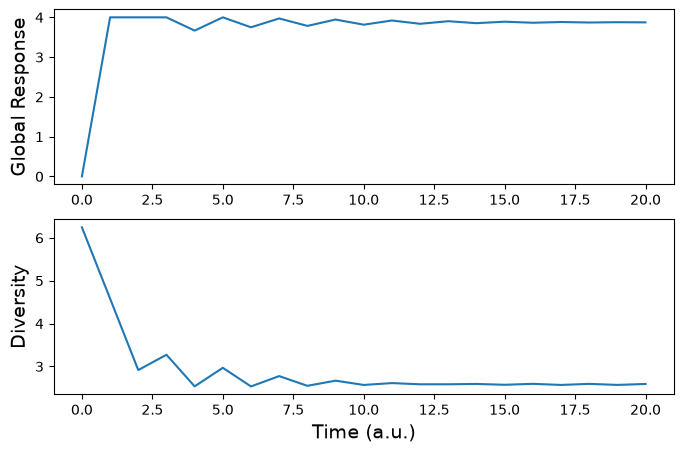

In [7]:
## COMPUTE AND VISUALISE SOME METRICS
globalresp = sna.GlobalResponse(resp_tensor, selfresp=False)
diversity = sna.Diversity(resp_tensor)

# Visualise the results
plt.figure(figsize=(8,5))
plt.subplot(2,1,1)
plt.plot(tpoints, globalresp.values);
plt.ylabel( 'Global Response' )

plt.subplot(2,1,2)
plt.plot(tpoints, diversity.values);
plt.xlabel( 'Time (a.u.)' )
plt.ylabel( 'Diversity' )

The results `globalresp` and `diversity` are new `xarray.DataArray` objects that inherit the 'time' dimension and the attributes from `resp_tensor`, but dropping the two *spatial* dimensions `'nodes_to'` and `'nodes_from'`.

In [92]:
globalresp
#diversity

<xarray.DataArray (time: 21)> Size: 168B
array([0.        , 4.        , 4.        , 4.        , 3.66666667,
       4.        , 3.75      , 3.97222222, 3.78472222, 3.94444444,
       3.81539352, 3.92071759, 3.83781829, 3.90287423, 3.85347946,
       3.89051649, 3.86375044, 3.88256735, 3.87005716, 3.87783466,
       3.87362987])
Coordinates:
  * time     (time) uint64 168B 0 1 2 3 4 5 6 7 8 ... 12 13 14 15 16 17 18 19 20
Attributes:
    model:       RandomWalk
    time_class:  discrete
    dt:          1.0
    S0:          [1. 3. 0. 0. 0. 0. 0. 0.]

#### Some node-wise properties

- **Node responses** are the (input) response of each node to all initial perturbations in other nodes, and the influence of the node (output response) to others. 
- **Self-responses** … 


In [8]:
sna.NodeResponses?

Signature: sna.NodeResponses(tensor, selfresp=True)
Docstring:
Temporal evolution of the input and output responses for each node.

Parameters
----------
tensor : xarray.DataArray of dimension 3 and shape (nt,N,N)
    Temporal evolution of the pair-wise responses, as calculated by one of
    the functions of module *responses.py*.
selfresp : boolean
    If `True` (default), returns the in-/out-responses of the nodes,
    summing also the self-responses: the response of a node to the
    initial stimulus applied on itself. That is, adds the diagonal $R_{ii}(t)$
    entries to the row and column sums.
    If `False`, excludes the response of a node to the stimulus applied on
    itself. Excludes the diagonal entries $R_{ii}(t)$ in the row and
    column sums.

Returns
-------
noderesp : tuple contaning two xarray.DataArrays of shape (nt,N).
    The temporal evolution of the input and output responses for all nodes.
    `node_resps[0]` is the input responses into the nodes node and
    `n

<br/>

## Example 1: First steps,  path (di)graphs

### Dynamic flow
We start by studying the flow and dynamic communicability on very simple graphs in order to understand basic concepts. Consider a chain graphs as the one with directed arcs in the figure below. We will characterise how a perturbation applied to the first node propagates along the chain.

<img src="Images/PathGraph_Directed1.png" style="float:center; width:500px; height:50px"  alt="Path Graph" />


In this first example we will: 
1. Create the digraph, 
2. calculate its spectral diameter to estimate the largest time-constant $\tau_{max}$ acceptable,
3. apply a perturbation at the first node,
4. explore the dynamic flow matrices over time, and 
5. visualise the node-wise input and output flows.

In [6]:
# Create a directed path graph of N = 6 nodes
N = 6
dirnet = galib.models.PathGraph(N, directed=True)

# Find the spectral radius and the largest time constant 
evs = numpy.linalg.eigvals(dirnet)
evsnorms = np.zeros(N, float)
for i in range(N):
    evsnorms[i] = numpy.linalg.norm(evs[i])
evmax = evsnorms.max()
maxtau = 1./evmax

print( 'Spectral radius:\t%2.5f' %evmax )
print( 'Largest possible tau:\t%2.5f' %maxtau )

Spectral radius:	0.00000
Largest possible tau:	inf


/Users/gorka/.edm/envs/py36/lib/python3.6/site-packages/ipykernel_launcher.py:11: RuntimeWarning: divide by zero encountered in double_scalars
  # This is added back by InteractiveShellApp.init_path()


For a given network represented by $A$, the tendency of the network dynamics to diverge is represented by the largest eigenvalue (spectral radious) $\lambda_{max}$ of $A$. To assure the convergence of the system the leakage along each node needs to counterbalance this tendency. For that, the condicion $\tau < \tau_{max}$ with $\tau_{max} = 1 \,/\, \lambda_{max}$ needs to be fulfilled. 
In this particular case, all the eigenvalues of the directed path graph are zero, thus, $\tau_{max} = \infty$ and the system converges for any value of $\tau$. But this will not be the case in general.

In order to have a flow, we need to define an _**external perturbation**_, which is encoded in the $\Sigma$ matrix as the covariances between the external Gaussian noisy inputs. Since here we only want to excite the first node, $\Sigma$ will be all zeros exept for the element $\Sigma_{00} = 1$.

In [7]:
# Set the matrix of noisy inputs
sigma = np.zeros((N,N), np.float)
sigma[0,0] = 1.0

# Set a time-constant
tau = 1.0

# Define the temporal resolution for the "simulation"
tfinal = 10
dt = 0.01
tpoints = np.arange(0.0, tfinal+dt, dt)
nsteps = len(tpoints)

# Calculate the dynamic flow for a time span between 0 and tmax
fullflow_dir = ndf.FullFlow(dirnet, tau, sigma, tmax=tfinal, timestep=dt, normed=True)
dynflow_dir = ndf.DynFlow(dirnet, tau, sigma, tmax=tfinal, timestep=dt, normed=True) 

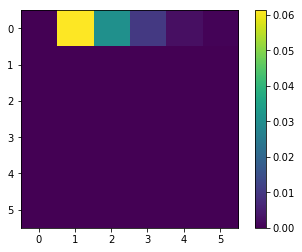

In [8]:
# Visualise the flow matrices at different times
plt.figure()
# Check for (temporal) indices: 0, 100, 200, 400, 600, 800
tidx = 100
plt.imshow(dynflow_dir[tidx])
plt.colorbar()


Text(0.5,0,'Time (a.u.)')

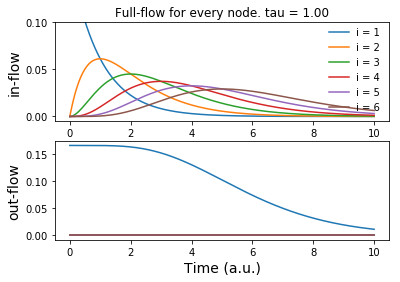

In [9]:
# Calculate the in-/out- full-flow for every node
# infullflow and outfullflow are two arrays of shape (N,nsteps)
infullflow_dir, outfullflow_dir = ndf.NodeEvolution(fullflow_dir)

# Plot a figure wit the input and output flows of every node
plt.figure()
plt.subplot(2,1,1)
plt.title('Full-flow for every node. tau = %1.2f' %tau, fontsize=12)
for i in range(N):
    plt.plot(tpoints, infullflow_dir[:,i], label='i = %d' %(i+1))
plt.ylim(-0.005,0.1)
plt.ylabel('in-flow', fontsize=14)
plt.legend(frameon=False)

plt.subplot(2,1,2)
for i in range(N):
    plt.plot(tpoints, outfullflow_dir[:,i], label='i = %d' %(i+1))
plt.ylabel('out-flow', fontsize=14)
plt.xlabel('Time (a.u.)', fontsize=14)

Text(0.5,0,'Time (a.u.)')

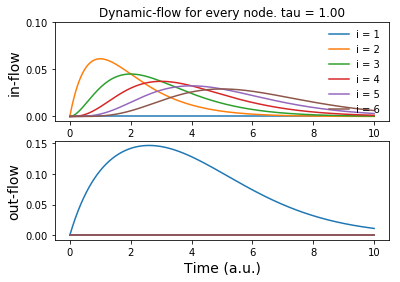

In [10]:
# Calculate the in-/out- dynamic-flow for every node
# inflow and outflow are two arrays of shape (N,nsteps)
inflow_dir, outflow_dir = ndf.NodeEvolution(dynflow_dir)

# Plot the input and output full-flow of every node
plt.figure()
plt.subplot(2,1,1)
plt.title('Dynamic-flow for every node. tau = %1.2f' %tau, fontsize=12)
for i in range(N):
    plt.plot(tpoints, inflow_dir[:,i], label='i = %d' %(i+1))
plt.ylim(-0.005,0.1)
plt.ylabel('in-flow', fontsize=14)
plt.legend(loc='center right', frameon=False)

plt.subplot(2,1,2)
for i in range(N):
    plt.plot(tpoints, outflow_dir[:,i], label='i = %d' %(i+1))
plt.ylabel('out-flow', fontsize=14)
plt.xlabel('Time (a.u.)', fontsize=14)


### Dynamic communicability

Flow is the general concept since it doesn't make any specific assumptions on which nodes are excited and even accepts correlated inputs across nodes (encoded as the extra-diagonal entries in $\Sigma$). We name *dynamic communicability* to the special case of the flow in which every node is perturbed by independent Gaussian noise of unit variance. The idea is illustrated as follows:

<img src="Images/PathGraph_Directed2.png" style="float:center; width:500px; height:50px"  alt="Path Graph" />

In this case, $\Sigma$ is the unitary matrix **1**. Therefore, the `ndf.DynCom()` function does not require the $\Sigma$ matrix as an explicit input.

We will now repeat the previous analysis for the new perturbation scheme.

In [11]:
# Calculate the dynamic communicability for a time span between 0 and tmax
dyncom_dir = ndf.DynCom(dirnet, tau, tmax=tfinal, timestep=dt, normed=True)

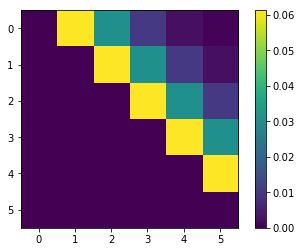

In [12]:
# Visualise the dynamic communicability matrices at different times
plt.figure()
# Check for (temporal) indices: 0, 100, 200, 400, 600, 800
tidx = 100
plt.imshow(dyncom_dir[tidx])
plt.colorbar()


Text(0.5,0,'Time (a.u.)')

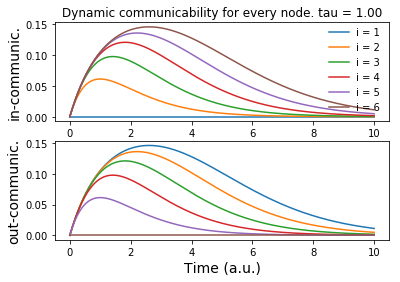

In [13]:
# Calculate the in-/out- dynamic communicability for every node
# indyncom and outdyncom are two arrays of shape (N,nsteps)
indyncom_dir, outdyncom_dir = ndf.NodeEvolution(dyncom_dir)

# Plot the input and output dynamic communicability of every node
plt.figure()
plt.subplot(2,1,1)
plt.title('Dynamic communicability for every node. tau = %1.2f' %tau, fontsize=12)
for i in range(N):
    plt.plot(tpoints, indyncom_dir[:,i], label='i = %d' %(i+1))
plt.ylabel('in-communic.', fontsize=14)
plt.legend(frameon=False)

plt.subplot(2,1,2)
for i in range(N):
    plt.plot(tpoints, outdyncom_dir[:,i], label='i = %d' %(i+1))
plt.ylabel('out-communic.', fontsize=14)
plt.xlabel('Time (a.u.)', fontsize=14)


We end this introductory example by repeating the calculations on chains with _**undirected links**_ and following the same perturbation protocols.

<img src="Images/PathGraph_Undirected1.png" style="float:center; width:500px; height:50px"  alt="Path Graph" />
<img src="Images/PathGraph_Undirected2.png" style="float:center; width:500px; height:50px"  alt="Path Graph" />

In this case, the perturbations can diffuse in both directions. Also, the largest eigenvalue $λ_{max}$ of the path graph is finite, thus imposing a limitation on $\tau$.
$$$$


In [14]:
# Create the undirected path graph of N = 6 nodes
N = 6
undnet = galib.models.PathGraph(N, directed=False)

# Find the spectral radius and the largest time constant 
evs = numpy.linalg.eigvals(undnet)
evsnorms = np.zeros(N, float)
for i in range(N):
    evsnorms[i] = numpy.linalg.norm(evs[i])
evmax = evsnorms.max()
maxtau = 1./evmax

print( 'Spectral radius:\t%2.5f' %evmax )
print( 'Largest possible tau:\t%2.5f' %maxtau)

Spectral radius:	1.80194
Largest possible tau:	0.55496


In [15]:
# Set the matrix of noisy inputs
sigma = np.zeros((N,N), np.float)
sigma[0,0] = 1.0
# Set a time-constant
tau = 0.45

# Define the temporal resolution
tfinal = 10
dt = 0.01
tpoints = np.arange(0.0, tfinal+dt, dt)
nsteps = len(tpoints)

# Calculate the dynamic flow for a time span between 0 and tmax
dynflow_und = ndf.DynFlow(undnet, tau, sigma, tmax=tfinal, timestep=dt, normed=True)
# Calculate the dynamic communicability for a time span between 0 and tmax
dyncom_und = ndf.DynCom(undnet, tau, tmax=tfinal, timestep=dt, normed=True)

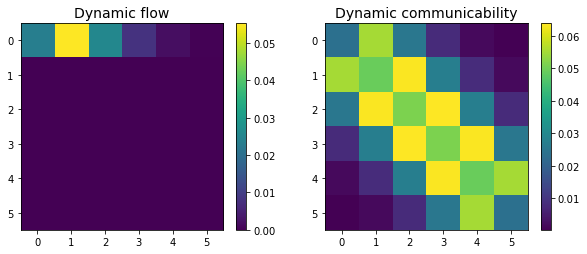

In [16]:
# Visualise the dynamic communicability matrices at different times
plt.figure(figsize=(10,3.8))

# Check for (temporal) indices: 0, 100, 200, 400, 600, 800
tidx = 100

# Plot the flow matrix
plt.subplot(1,2,1)
plt.title('Dynamic flow', fontsize=14)
plt.imshow(dynflow_und[tidx], aspect='auto')
plt.colorbar()

# Plot the flow matrix
plt.subplot(1,2,2)
plt.title('Dynamic communicability', fontsize=14)
plt.imshow(dyncom_und[tidx], aspect='auto')
plt.colorbar()

#plt.tight_layout()


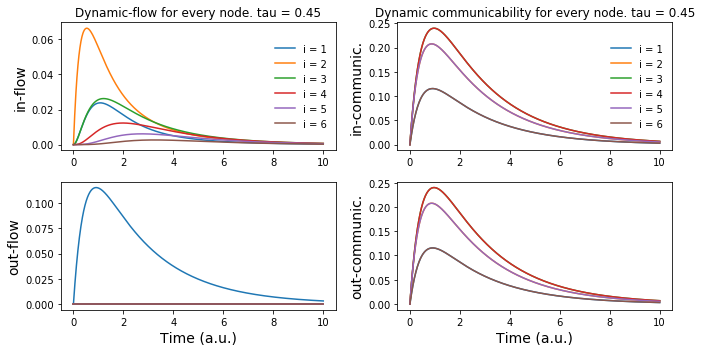

In [17]:
# Calculate the in-/out- dynamic flow and communicability for every node
inflow_und, outflow_und = ndf.NodeEvolution(dynflow_und)
indyncom_und, outdyncom_und = ndf.NodeEvolution(dyncom_und)

# Plot the input and output results for every node
plt.figure(figsize=(10,5))
# Plot the results for the in-/out-flow
plt.subplot(2,2,1)
plt.title('Dynamic-flow for every node. tau = %1.2f' %tau, fontsize=12)
for i in range(N):
    plt.plot(tpoints, inflow_und[:,i], label='i = %d' %(i+1))
#pp.ylim(-0.005,0.1)
plt.ylabel('in-flow', fontsize=14)
plt.legend(loc='center right', frameon=False)

plt.subplot(2,2,3)
for i in range(N):
    plt.plot(tpoints, outflow_und[:,i], label='i = %d' %(i+1))
plt.ylabel('out-flow', fontsize=14)
plt.xlabel('Time (a.u.)', fontsize=14)

# Plot the results for the in-/out-dynamic communicability
plt.subplot(2,2,2)
plt.title('Dynamic communicability for every node. tau = %1.2f' %tau, fontsize=12)
for i in range(N):
    plt.plot(tpoints, indyncom_und[:,i], label='i = %d' %(i+1))
plt.ylabel('in-communic.', fontsize=14)
plt.legend(loc='center right', frameon=False)

plt.subplot(2,2,4)
for i in range(N):
    plt.plot(tpoints, outdyncom_und[:,i], label='i = %d' %(i+1))
plt.ylabel('out-communic.', fontsize=14)
plt.xlabel('Time (a.u.)', fontsize=14)

plt.tight_layout()


<br/>

## Example 2: Weighted ring lattices and comparison to surrogates

Now we will consider ring networks where links are weighted. We will:

1. Create and study a directed ring with random link weights.
2. Create and study an undirected ring with random link weights.
3. Compare to weighted open loops (weighted path graphs).
4. Randomise links and compare.
5. Add further connectivity.


### Directed ring with weighted links

We start by studying a directed ring whose links are weighted, see illustration below. The link weights will be randomly assigned from a normal distribution with mean `c0` and variance `w_spread`. In this case the global feedback is thus controled by `c0` and the heterogeneity of weights by `w_spread`.


<img src="Images/RingDigraph.png" style="float:center; width:200px; height:200px"  alt="Directed Ring" />


Setting the number of nodes to *N = 4* would reproduce results in Figs. 2 and 3 in the paper:  Gilson M, Kouvaris NE, Deco G, Zamora-López G (2018) *Phys Rev E* **97**, 052301 (https://doi.org/10.1103/PhysRevE.97.052301).



Text(0,0.5,'Source node')

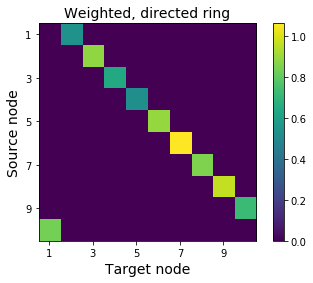

In [18]:
# Create a directed ring with random link weights
N = 10
c0 = 0.8
w_spread = 0.4

C_dir = np.zeros([N,N])
for i in range(N):
    C_dir[i-1,i] = c0 * (1 + 2*w_spread*(np.random.rand() - 0.5))

# Visualise the connectivity matrix
axticks = np.arange(0,N,2)

plt.figure()
plt.title('Weighted, directed ring', fontsize=14)
plt.imshow(C_dir, interpolation='nearest')
plt.xticks(axticks, axticks+1, fontsize=10)
plt.yticks(axticks, axticks+1, fontsize=10)
plt.colorbar()
plt.xlabel('Target node', fontsize=14)
plt.ylabel('Source node', fontsize=14)



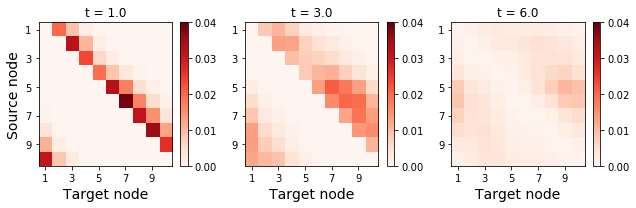

In [19]:
# Calculate the dynamic communicability 
# Define the temporal resolution for the "simulation"
tfinal = 20
dt = 0.2
tpoints = np.arange(0.0, tfinal+dt, dt)
nsteps = len(tpoints)

# Set a time-constant for the leakage at the nodes
tau = 1.0

# Calculate dynamic communicability
dc_dir = ndf.DynCom(C_dir, tau, tmax=tfinal, timestep=dt)

# Visualise the communicability matrix at three different integration times
plt.figure(figsize=(9,3))
axticks = np.arange(0,N,2)
for idx, t in enumerate([1,3,6]):
    plt.subplot(1,3,idx+1)
    plt.title('t = %1.1f' %t, fontsize=12)
    plt.imshow(dc_dir[int(t/dt)], interpolation='nearest', aspect='auto', cmap='Reds')
    plt.clim(0, 0.04)
    plt.xticks(axticks, axticks+1, fontsize=10)
    plt.yticks(axticks, axticks+1, fontsize=10)
    plt.colorbar(ticks=[0,0.01,0.02, 0.03, 0.04])
    plt.xlabel('Target node', fontsize=14)
    if idx==0: plt.ylabel('Source node', fontsize=14)

plt.tight_layout()


#### Network and node-wise characterization with dynamic communicability

The coarse-grained, general behaviour of the network over time can be evaluated by _**total communicability**_, which is defined as the sum of all pair-wise interactions between nodes. Thus, total communicability characterises the global network feedback. In this example it depends on the mean link weight `c0`.

The communicability passing through a node depends not only on its closest neighbours, but reflects the role that each node plays in the global communication of the network. The temporal evolution of a node's communicability is calculated as the "row" or "column" sum of the communicability matrix, at each time point. If the network is symmetric, both sums will be the same. If the network is directed (asymmetic), then input (column sum) and output (row sum) communicabilies reflect a node's capacity to integrate or to broadcast information respectively.

In the following, we will show the total and node-wise communicability of the weigthed and directed ring we just created.

Text(0,0.5,'total communicability')

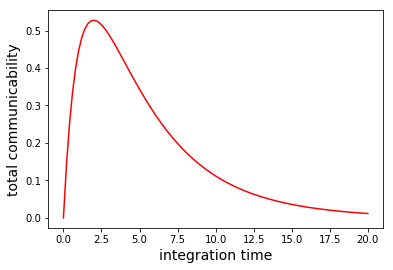

In [20]:
# Calculate total communicability. Use the generic function to estimate tensor sum over time.
totcomm_dir = ndf.TotalEvolution(dc_dir)

plt.figure()
plt.plot(tpoints, totcomm_dir, color='red')
plt.xlabel('integration time', fontsize=14)
plt.ylabel('total communicability', fontsize=14)


Text(0.5,1,'Output communicability')

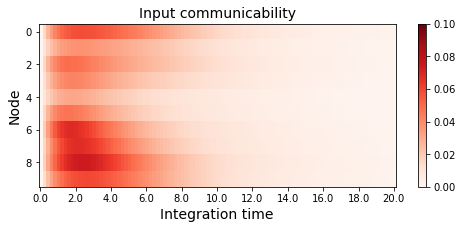

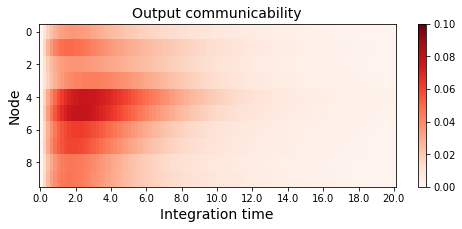

In [21]:
# Calculate the input and output communicabilities for each node, over integration time
# Use the generic function to estimate node-wise averages from the time-flow tensor
in_dc, out_dc = ndf.NodeEvolution(dc_dir)

# Visualise the in-/out-communicabilities as an image
xtick_idx = np.arange(0,nsteps+1,10)
xtick_labs = tpoints[xtick_idx]

# Plot the input communicabilities
plt.figure(figsize=(8,3))
plt.imshow(in_dc.T, aspect='auto', cmap='Reds', vmin=0, vmax=0.1)
plt.xticks(xtick_idx, xtick_labs)
plt.xlabel('Integration time',fontsize=14)
plt.ylabel('Node', fontsize=14)
plt.colorbar()
plt.title('Input communicability', fontsize=14)

# Plot the output communicabilities
plt.figure(figsize=(8,3))
plt.imshow(out_dc.T, aspect='auto', cmap='Reds', vmin=0, vmax=0.1)
plt.xticks(xtick_idx, xtick_labs)
plt.xlabel('Integration time', fontsize=14)
plt.ylabel('Node',fontsize=14)
plt.colorbar()
plt.title('Output communicability', fontsize=14)


#### Diversity

As we saw before, the communicability matrices change over time. Initially the interactions tend to be aligned with the links in the connectivity matrix. At later integration times the interactions capture nontrivial network feedback, and finally the pattern of interactions homogenises. We quantify the heterogeneity of pair-wise communicabiltiy values as the coefficient of variance in the communicability matrix at each time; a metric we refer as _**diversity**_.

We now show a direct comparison between the original link weights in the connectivity matrix `C` and the values that the pair-wise communicability take; illustrating its process of homogeneization over time.

Text(0,0.5,'Diversity')

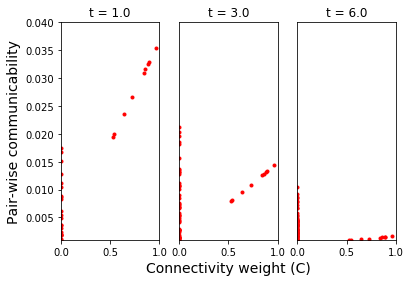

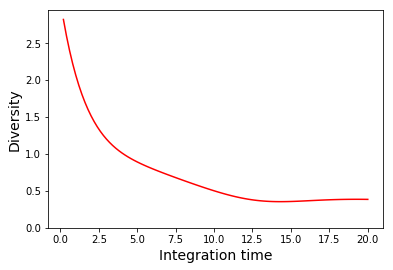

In [22]:
# Plot the comparison between the connectivity weights and communicability over time.
plt.figure()
for i, t in enumerate([1,3,6]):
    plt.subplot(1,3,i+1)
    plt.plot(C_dir, dc_dir[int(t/dt)], '.r')
    if i==1:
        plt.xlabel('Connectivity weight (C)', fontsize=14)
    if i==0:
        plt.ylabel('Pair-wise communicability', fontsize=14)
    else:
        plt.yticks([])
    plt.axis(xmin=-0.001, xmax=1, ymin=0.001, ymax=0.04)
    plt.title('t = %1.1f' %t)


# Compute the diversity over time from the dyn. comm. tensor
divers_dir = ndf.Diversity(dc_dir)

# Plot the temporal evolution of the diversity
plt.figure()
plt.plot(tpoints, divers_dir, color='r')
plt.axis(ymin=0)
plt.xlabel('Integration time', fontsize=14)
plt.ylabel('Diversity', fontsize=14)


### Undirected ring with weighted links

We now repeat the analysis considering the ring network is **undirected**, as in the figure below. The undirected ring will be constructed symmetrising the directed ring we created before. **Notice that** the symmetrization conserves the total weight of matrix.

<img src="Images/RingGraph.png" style="float:center; width:200px; height:200px"  alt="Undirected Ring" />


Text(0,0.5,'Source node')

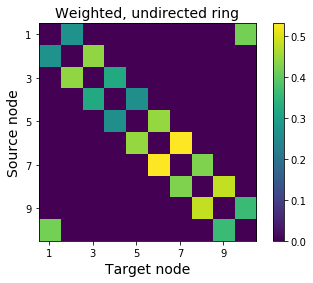

In [23]:
# Create the symmetric version of the original directed ring
C_sym = 0.5 * (C_dir + C_dir.T)

# Visualise the new connectivity matrix
axticks = np.arange(0,N,2)

plt.figure()
plt.title('Weighted, undirected ring', fontsize=14)
plt.imshow(C_sym, interpolation='nearest')
plt.xticks(axticks, axticks+1, fontsize=10)
plt.yticks(axticks, axticks+1, fontsize=10)
plt.colorbar()
plt.xlabel('Target node', fontsize=14)
plt.ylabel('Source node', fontsize=14)



Text(0,0.5,'Total communicability')

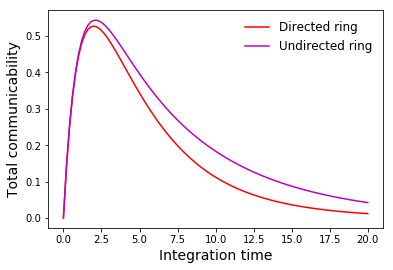

In [24]:
# Compare the dynamic communicability for directed and undirected cases
# Calculate DC for the symmetric network - using same temporal resolution
dc_sym =  ndf.DynCom(C_sym, tau, tmax=tfinal, timestep=dt)

# Calculate total communicability. Use the generic function to estimate tensor sum over time.
totcomm_sym = ndf.TotalEvolution(dc_sym)


# Visualise the comparison
plt.figure()
plt.plot(tpoints, totcomm_dir, c='r', label='Directed ring')
plt.plot(tpoints, totcomm_sym, c='m', label='Undirected ring')
plt.legend(frameon=False, fontsize=12)
plt.xlabel('Integration time', fontsize=14)
plt.ylabel('Total communicability', fontsize=14)


As seen, the undirected ring achieves larger total communicability due to the reinforced recurrent feedback created when making the links bidirectional.
Finally, we confirm that in the symmetrised case the input and output node communicabilities are symmetric, and different from the original directed case.

Text(0.5,1,'Output communicability')

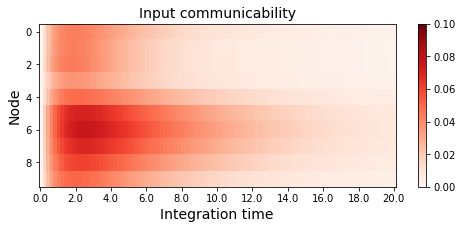

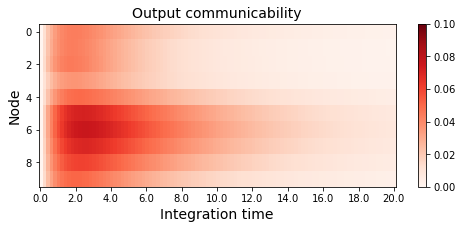

In [25]:
# Calculate the communicabilities for each node, over integration time
# Use the generic function to estimate node-wise averages from the time-flow tensor
in_dcsym, out_dcsym = ndf.NodeEvolution(dc_sym)

# Visualise the in-/out-communicabilities as an image
xtick_idx = np.arange(0,nsteps+1,10)
xtick_labs = tpoints[xtick_idx]

# Plot the input communicabilities
plt.figure(figsize=(8,3))
plt.imshow(in_dcsym.T, aspect='auto', cmap='Reds', vmin=0, vmax=0.1)
plt.xticks(xtick_idx, xtick_labs)
plt.xlabel('Integration time',fontsize=14)
plt.ylabel('Node', fontsize=14)
plt.colorbar()
plt.title('Input communicability', fontsize=14)

# Plot the output communicabilities
plt.figure(figsize=(8,3))
plt.imshow(out_dcsym.T, aspect='auto', cmap='Reds', vmin=0, vmax=0.1)
plt.xticks(xtick_idx, xtick_labs)
plt.xlabel('Integration time', fontsize=14)
plt.ylabel('Node',fontsize=14)
plt.colorbar()
plt.title('Output communicability', fontsize=14)



### Weighted open loops (path graphs)

Finally, we will compare the results obtained for the loops to those of open chains, as the ones studied in the Example-1 but with the same link weights as in the present examples. To create the open chains we will remove the links between the first and the last node in the two loops generated. The link weights will also be rescaled in order to assure all the networks have equal total weight.

We will (i) calculate their dynamic communicability and diversity, and (ii) plot the comparison of all the cases.

In [26]:
# Create the directed open chain from the directed loop
C_opendir = np.copy(C_dir)
C_opendir[-1,0] = 0
# Renormalise the total weight
C_opendir *= C_dir.sum() / C_opendir.sum()

# Create the undirected open chain from the symmetric loop
C_opensym = np.copy(C_sym)
C_opensym[-1,0] = 0
C_opensym[0,-1] = 0
# Renormalise the total weight
C_opensym *= C_sym.sum() / C_opensym.sum()

print( 'Confirm total weights:' )
print( C_dir.sum(), C_opendir.sum(), C_sym.sum(), C_opensym.sum() )

Confirm total weights:
7.943118027451687 7.943118027451688 7.943118027451686 7.943118027451686


Text(0,0.5,'Total communicability')

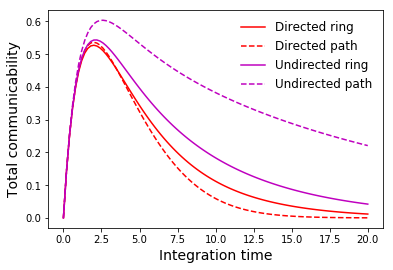

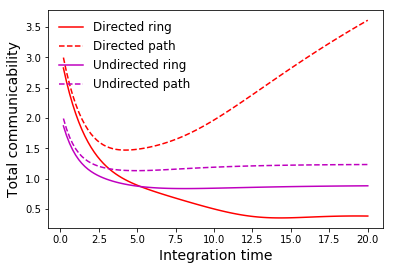

In [27]:
# Calculate dynamic communicability for the open chains
dc_opendir =  ndf.DynCom(C_opendir, tau, tmax=tfinal, timestep=dt)
dc_opensym =  ndf.DynCom(C_opensym, tau, tmax=tfinal, timestep=dt)

# Calculate the total communicabilities of the open chains
totcomm_opendir = ndf.TotalEvolution(dc_opendir)
totcomm_opensym = ndf.TotalEvolution(dc_opensym)

# Calcultate the diversities
divers_sym = ndf.Diversity(dc_sym)
divers_opendir = ndf.Diversity(dc_opendir)
divers_opensym = ndf.Diversity(dc_opensym)


# Visualise the comparisons
# Plot the total communicability
plt.figure()
plt.plot(tpoints, totcomm_dir, c='r', label='Directed ring')
plt.plot(tpoints, totcomm_opendir, c='r', ls='--', label='Directed path')
plt.plot(tpoints, totcomm_sym, c='m', label='Undirected ring')
plt.plot(tpoints, totcomm_opensym, c='m', ls='--', label='Undirected path')
plt.legend(frameon=False, fontsize=12)
plt.xlabel('Integration time', fontsize=14)
plt.ylabel('Total communicability', fontsize=14)

# GORKA: I ADDED THE DIVERSITY BUT... NOT SURE IT WAS A GOOD IDEA
# Plot the diversity
plt.figure()
plt.plot(tpoints, divers_dir, c='r', label='Directed ring')
plt.plot(tpoints, divers_opendir, c='r', ls='--', label='Directed path')
plt.plot(tpoints, divers_sym, c='m', label='Undirected ring')
plt.plot(tpoints, divers_opensym, c='m', ls='--', label='Undirected path')
plt.legend(frameon=False, fontsize=12)
plt.xlabel('Integration time', fontsize=14)
plt.ylabel('Total communicability', fontsize=14)


<br>

TO BE CONTINUED ...